EXPERIMENT 4: DATA WRANGLING AND DATA VISUALIZATION 

In [80]:
import pandas as pd 
import matplotlib.pyplot as plt 

In [81]:
board2= pd.read_excel('board2.xlsx')

A. VISAYAS COMMUNICATION DATAFRAME 

In [82]:
board2['Average']=board2[['Math','Electronics','GEAS','Communication']].mean(axis=1)
board2

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
0,S1,Male,Instrumentation,Luzon,58,89,75,78,75.00
1,S2,Female,Communication,Mindanao,52,75,90,52,67.25
2,S3,Female,Instrumentation,Mindanao,83,74,77,57,72.75
3,S4,Male,Instrumentation,Visayas,65,58,91,68,70.50
4,S5,Male,Communication,Luzon,59,86,43,88,69.00
5,S6,Female,Microelectronics,Visayas,88,45,86,83,75.50
6,S7,Female,Instrumentation,Luzon,66,60,60,48,58.50
7,S8,Male,Instrumentation,Luzon,49,81,64,53,61.75
8,S9,Male,Instrumentation,Luzon,50,36,63,42,47.75
9,S10,Male,Microelectronics,Mindanao,80,84,61,44,67.25


In [83]:
VisComm = board2.loc[(board2['Hometown']=='Visayas')&(board2['Track']=='Communication'),['Name','Gender','Math','Electronics','Average'],]
VisComm

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


In [84]:
print(f'Number of Rows: {len(VisComm)}')
display(VisComm)

Number of Rows: 5


,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


B. VISAYAS FEMALE DATAFRAME 

In [85]:
VisFemale = board2.loc[(board2['Hometown']=='Visayas')&(board2['Gender']=='Female'),['Name','Track','GEAS','Electronics','Average'],]
VisFemale 

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


In [86]:
display(VisFemale)
display(VisFemale.loc[(VisFemale['Average']>=60)])


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


C. CATEGORY-AVERAGE VISUALIZATION

In [87]:
track_mean = board2.groupby('Track')['Average'].mean().reset_index()
gender_mean = board2.groupby('Gender')['Average'].mean().reset_index()
hometown_mean = board2.groupby('Hometown')['Average'].mean().reset_index()

display(track_mean)
display(gender_mean)
display(hometown_mean)

,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500


,Gender,Average
0,Female,66.616667
1,Male,67.183333


,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


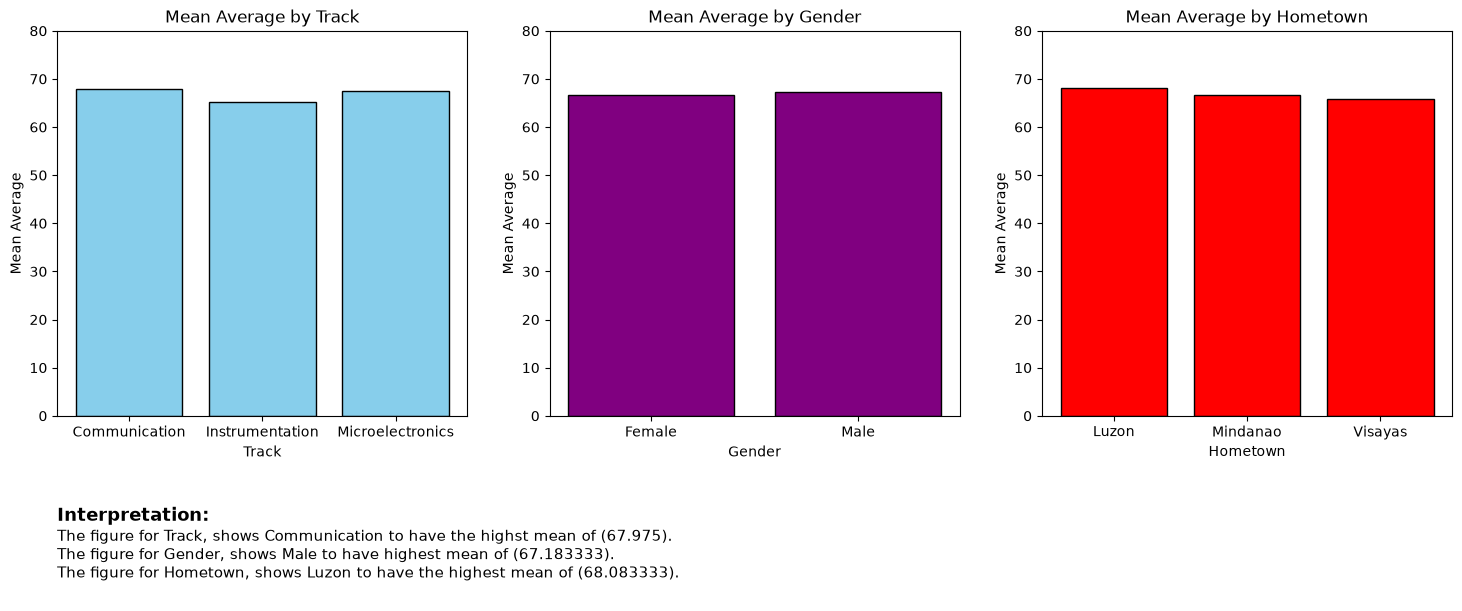

In [88]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

axes[0].bar(track_mean['Track'], track_mean['Average'], color='skyblue',edgecolor='black')
axes[0].set_title('Mean Average by Track')
axes[0].set_xlabel('Track')
axes[0].set_ylabel('Mean Average')
axes[0].set_ylim(0,80)

axes[1].bar(gender_mean['Gender'], gender_mean['Average'], color='purple',edgecolor='black')
axes[1].set_title('Mean Average by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Mean Average')
axes[1].set_ylim(0,80)

axes[2].bar(hometown_mean['Hometown'], hometown_mean['Average'], color='red',edgecolor='black')
axes[2].set_title('Mean Average by Hometown')
axes[2].set_xlabel('Hometown')
axes[2].set_ylabel('Mean Average')
axes[2].set_ylim(0,80)

fig.text(0.125,-0.1,'Interpretation:', weight='bold',size=13)
fig.text(0.125,-0.25, 'The figure for Track, shows Communication to have the highst mean of (67.975).\n'
           'The figure for Gender, shows Male to have highest mean of (67.183333).\n'
           'The figure for Hometown, shows Luzon to have the highest mean of (68.083333).\n', size=11)

plt.show()